# Modeling with Land Cover Type included.

This notebook is picking up where the last tree_model_final notebook left off. We're exploring how adding in landcover types improves the models (if at all).

In the notebook you will find the below:

1. [Data and EDA](#read-in-data-and-eda)
2. [Setting up the model](#setting-up-the-model)
3. [Baseline model](#baseline-model)
4. [Hyperparameter tuning](#hyperparameter-tuning)
5. [Comparing the results](#results-comparison)


The different data sources:
1. `../data/target/model_training_data_final_with_lc.csv` 
2. `../data/target/model_training_data_final_urban.csv`
3. `../data/target/model_training_data_final_urban_only.csv`
4. `../data/target/model_training_data_final.csv`

Read in the necessary libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor, HistGradientBoostingRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, root_mean_squared_error, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve,precision_score, recall_score
import seaborn as sns
import warnings
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import networkx as nx
from itertools import product
import pickle
import lightgbm as lgb
import xgboost as xgb
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.exceptions import DataConversionWarning
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVR
import os 
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import copy
from rasterstats import zonal_stats
import geopandas as gpd
import numpy as np
import rasterio
import sys
import os 
from osgeo import ogr  
ogr.UseExceptions()
from datetime import datetime, timedelta
import warnings
import shapefile
import csv
from rasterio.crs import CRS
from shapely.geometry import shape
from shapely import wkt
from shapely.geometry import Point
from shapely.strtree import STRtree
from shapely.geometry import box
import psutil
import shutil
from pathlib import Path
import re
import json
import xarray as xr
plt.rcParams['font.family'] = 'Helvetica'
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings('ignore', category=DataConversionWarning)
%matplotlib inline

thesis_cmap_div = mcolors.LinearSegmentedColormap.from_list(
    "thesis_div",
    [
        '#F6511D',
        '#EAF2EF',
        '#097FC7',
    ]
)

plt.rcParams['font.family'] = 'Helvetica'

BACKGROUND_COLOR = '#EAF2EF'

%load_ext autoreload
%autoreload 2

from helper_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Needed Function Definitions**

In [ ]:
def describe_row_missingness(df):
    """
    Analyses and describes missing values per row.
    """
    n_cols   = df.shape[1]
    row_miss = df.isna().sum(axis=1) / n_cols

    print("Row missingness distribution")
    print(row_miss.describe().round(4))
    print(f"\nRows with any missing:  {(row_miss > 0).sum()} ({(row_miss > 0).mean()*100:.1f}%)")
    print(f"Rows with >10% missing: {(row_miss > 0.10).sum()} ({(row_miss > 0.10).mean()*100:.1f}%)")
    print(f"Rows with >25% missing: {(row_miss > 0.25).sum()} ({(row_miss > 0.25).mean()*100:.1f}%)")
    print(f"Rows with >50% missing: {(row_miss > 0.50).sum()} ({(row_miss > 0.50).mean()*100:.1f}%)")
    print(f"Rows with 100% missing: {(row_miss == 1.0).sum()} ({(row_miss == 1.0).mean()*100:.1f}%)")

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)
    ax.hist(row_miss, bins=50, color='#097FC7', edgecolor='none')
    ax.axvline(row_miss.mean(), color='#F6511D', linestyle='--', lw=1.5,
               label=f'Mean: {row_miss.mean():.2f}')
    ax.set_xlabel("Proportion of missing values per row")
    ax.set_ylabel("Count")
    ax.set_title("Row-level missingness distribution")
    ax.legend()
    plt.tight_layout()
    plt.savefig('../figures/row_missingness.png', dpi=150, bbox_inches='tight',
                facecolor=BACKGROUND_COLOR)
    plt.show()

    return row_miss


def drop_rows_by_missingness(df, threshold):
    """
    Drops rows where missingness proportion exceeds threshold.

    Parameters
    ----------
    df        : DataFrame to filter
    threshold : float 0-1, drop rows where missingness > threshold

    Returns
    -------
    df_clean  : filtered DataFrame
    """
    n_cols   = df.shape[1]
    row_miss = df.isna().sum(axis=1) / n_cols
    mask     = row_miss <= threshold
    df_clean = df[mask]

    print(f"Dropped {(~mask).sum()} rows above {threshold*100:.0f}% missingness threshold")
    print(f"Remaining: {len(df_clean)} from {len(df)}")

    return df_clean



Read in the already cleaned and split data:

In [33]:
# read in complex filled data
df = pd.read_csv('../data/target/model_training_data_final_with_lc.csv')
df = df[df['smod_urban_suburban_perc'] > 0.10]
X_train_c, X_test_c, y_train_c, y_test_c = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

# read in simple filled data
X_train_s, X_test_s, y_train_s, y_test_s = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='simple')


In [34]:
df.shape

(17458, 81)

Quick baseline models with both sets:

In [35]:
# trying three random other models to see how they compare

# lightgbm
print("for RandomForest:")
rf_b_model = RandomForestRegressor(random_state=42, n_jobs=-1,verbose=0);
rf_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(rf_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_rfb = rf_b_model.predict(X_test_c)
test_r2_rfb = r2_score(y_test_c, y_pred_rfb)
print(f"Test Set R²: {test_r2_rfb:.4f}")

print("for ExtraTrees:")
ex_b_model = ExtraTreesRegressor(random_state=42, n_jobs=-1,verbose=0);
ex_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(ex_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_exb = ex_b_model.predict(X_test_c)
test_r2_exb = r2_score(y_test_c, y_pred_exb)
print(f"Test Set R²: {test_r2_exb:.4f}")

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_c, y_train_c)

scores = cross_val_score(lgb_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_c)
test_r2_lgb = r2_score(y_test_c, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_c, y_train_c)

scores = cross_val_score(hgbr_model, X_train_c, y_train_c, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_c)
test_r2_hgbr = r2_score(y_test_c, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

print("for BaggingRegressor:")
br_model = BaggingRegressor(random_state=42, n_jobs=-1, verbose=0)
br_model.fit(X_train_c, y_train_c)

scores = cross_val_score(br_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_br = br_model.predict(X_test_c)
test_r2_br = r2_score(y_test_c, y_pred_br)
print(f"Test Set R²: {test_r2_br:.4f}")

print("for GradientBoostingRegressor:")
gbr_model = GradientBoostingRegressor(random_state=42,verbose=0)
gbr_model.fit(X_train_c, y_train_c)

scores = cross_val_score(gbr_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_gbr = gbr_model.predict(X_test_c)
test_r2_gbr = r2_score(y_test_c, y_pred_gbr)
print(f"Test Set R²: {test_r2_gbr:.4f}")

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
xgb_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(xgb_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_xgbb = xgb_b_model.predict(X_test_c)
test_r2_xgbb = r2_score(y_test_c, y_pred_xgbb)
print(f"Test Set R²: {test_r2_xgbb:.4f}")

# SVR requires scaling
print("for SVR:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train_c.values.ravel())

scores = cross_val_score(svr_model, X_train_scaled, y_train_c.values.ravel(), cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_svr = svr_model.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test_c, y_pred_svr):.4f}")

#Results:
# for RandomForest:
# mean CV score: 0.2572
# Test Set R²: 0.3340
# for ExtraTrees:
# mean CV score: 0.1586
# Test Set R²: 0.3038
# for LGBM:
# mean CV score: 0.2382
# Test Set R²: 0.3056
# for HistGradientBoostingRegressor:
# mean CV score: 0.2364
# Test Set R²: 0.2871
# for BaggingRegressor:
# mean CV score: 0.1889
# Test Set R²: 0.2291
# for GradientBoostingRegressor:
# mean CV score: 0.1506
# Test Set R²: 0.1648
# for XGBRegressor:
# mean CV score: 0.1675
# Test Set R²: 0.2617
# for SVR:
# mean CV score: -0.0099
# Test R²: -0.0106

for RandomForest:
mean CV score: 0.1441
Test Set R²: 0.2273
for ExtraTrees:
mean CV score: 0.2108
Test Set R²: 0.2609
for LGBM:
mean CV score: 0.1883
Test Set R²: 0.2658
for HistGradientBoostingRegressor:
mean CV score: 0.2006
Test Set R²: 0.2935
for BaggingRegressor:
mean CV score: 0.0497
Test Set R²: 0.2002
for GradientBoostingRegressor:
mean CV score: 0.1051
Test Set R²: 0.1722
for XGBRegressor:
mean CV score: 0.1013
Test Set R²: 0.1906
for SVR:
mean CV score: -0.0096
Test R²: -0.0120


Ok, these are preforming better than the original baseline, so now we're trying with the masked layer as well:

In [44]:
# read in complex filled data
df = pd.read_csv('../data/target/model_training_data_final_urban.csv')
df = df[df['no_aff_data'] == 0]
X_train_c, X_test_c, y_train_c, y_test_c = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')



In [30]:
# trying three random other models to see how they compare

# lightgbm
print("for RandomForest:")
rf_b_model = RandomForestRegressor(random_state=42, n_jobs=-1,verbose=0);
rf_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(rf_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_rfb = rf_b_model.predict(X_test_c)
test_r2_rfb = r2_score(y_test_c, y_pred_rfb)
print(f"Test Set R²: {test_r2_rfb:.4f}")

print("for ExtraTrees:")
ex_b_model = ExtraTreesRegressor(random_state=42, n_jobs=-1,verbose=0);
ex_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(ex_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_exb = ex_b_model.predict(X_test_c)
test_r2_exb = r2_score(y_test_c, y_pred_exb)
print(f"Test Set R²: {test_r2_exb:.4f}")

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_c, y_train_c)

scores = cross_val_score(lgb_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_c)
test_r2_lgb = r2_score(y_test_c, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_c, y_train_c)

scores = cross_val_score(hgbr_model, X_train_c, y_train_c, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_c)
test_r2_hgbr = r2_score(y_test_c, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

print("for BaggingRegressor:")
br_model = BaggingRegressor(random_state=42, n_jobs=-1, verbose=0)
br_model.fit(X_train_c, y_train_c)

scores = cross_val_score(br_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_br = br_model.predict(X_test_c)
test_r2_br = r2_score(y_test_c, y_pred_br)
print(f"Test Set R²: {test_r2_br:.4f}")

print("for GradientBoostingRegressor:")
gbr_model = GradientBoostingRegressor(random_state=42,verbose=0)
gbr_model.fit(X_train_c, y_train_c)

scores = cross_val_score(gbr_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_gbr = gbr_model.predict(X_test_c)
test_r2_gbr = r2_score(y_test_c, y_pred_gbr)
print(f"Test Set R²: {test_r2_gbr:.4f}")

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
xgb_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(xgb_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_xgbb = xgb_b_model.predict(X_test_c)
test_r2_xgbb = r2_score(y_test_c, y_pred_xgbb)
print(f"Test Set R²: {test_r2_xgbb:.4f}")

# SVR requires scaling
print("for SVR:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train_c.values.ravel())

scores = cross_val_score(svr_model, X_train_scaled, y_train_c.values.ravel(), cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_svr = svr_model.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test_c, y_pred_svr):.4f}")

#Results:
# for RandomForest:
# mean CV score: 0.2119
# Test Set R²: 0.1660
# for ExtraTrees:
# mean CV score: 0.1604
# Test Set R²: 0.1288
# for LGBM:
# mean CV score: 0.2045
# Test Set R²: 0.1600
# for HistGradientBoostingRegressor:
# mean CV score: 0.1806
# Test Set R²: 0.1550
# for BaggingRegressor:
# mean CV score: 0.1472
# Test Set R²: 0.0848
# for GradientBoostingRegressor:
# mean CV score: 0.1159
# Test Set R²: 0.1222
# for XGBRegressor:
# mean CV score: 0.0911
# Test Set R²: 0.0810
# for SVR:
# mean CV score: -0.0084
# Test R²: -0.0082


# for RandomForest:
# mean CV score: 0.2416
# Test Set R²: 0.3172
# for ExtraTrees:
# mean CV score: 0.2130
# Test Set R²: 0.2432
# for LGBM:
# mean CV score: 0.2131
# Test Set R²: 0.3242
# for HistGradientBoostingRegressor:
# mean CV score: 0.1936
# Test Set R²: 0.3037
# for BaggingRegressor:
# mean CV score: 0.1693
# Test Set R²: 0.2776
# for GradientBoostingRegressor:
# mean CV score: 0.1728
# Test Set R²: 0.2054
# for XGBRegressor:
# mean CV score: 0.1246
# Test Set R²: 0.3329
# for SVR:
# mean CV score: -0.0114
# Test R²: -0.0124

for RandomForest:
mean CV score: 0.2416
Test Set R²: 0.3172
for ExtraTrees:
mean CV score: 0.2130
Test Set R²: 0.2432
for LGBM:
mean CV score: 0.2131
Test Set R²: 0.3242
for HistGradientBoostingRegressor:
mean CV score: 0.1936
Test Set R²: 0.3037
for BaggingRegressor:
mean CV score: 0.1693
Test Set R²: 0.2776
for GradientBoostingRegressor:
mean CV score: 0.1728
Test Set R²: 0.2054
for XGBRegressor:
mean CV score: 0.1246
Test Set R²: 0.3329
for SVR:
mean CV score: -0.0114
Test R²: -0.0124


The last option is the final version of the data with only the urban category!

In [110]:
# read in complex filled data
df_uo = pd.read_csv('../data/target/model_training_data_final_urban_only.csv')
# df = df[df['no_aff_data'] == 0]
X_train_uo, X_test_uo, y_train_uo, y_test_uo = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

In [58]:
print("for RandomForest:")
rf_b_model = RandomForestRegressor(random_state=42, n_jobs=-1,verbose=0);
rf_b_model.fit(X_train_uo, y_train_uo)

scores = cross_val_score(rf_b_model, X_train_uo, y_train_uo, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_rfb = rf_b_model.predict(X_test_uo)
test_r2_rfb = r2_score(y_test_uo, y_pred_rfb)
print(f"Test Set R²: {test_r2_rfb:.4f}")

print("for ExtraTrees:")
ex_b_model = ExtraTreesRegressor(random_state=42, n_jobs=-1,verbose=0);
ex_b_model.fit(X_train_uo, y_train_uo)

scores = cross_val_score(ex_b_model, X_train_uo, y_train_uo, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_exb = ex_b_model.predict(X_test_uo)
test_r2_exb = r2_score(y_test_uo, y_pred_exb)
print(f"Test Set R²: {test_r2_exb:.4f}")

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_uo, y_train_uo)

scores = cross_val_score(lgb_model, X_train_uo, y_train_uo, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_uo)
test_r2_lgb = r2_score(y_test_uo, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_uo, y_train_uo)

scores = cross_val_score(hgbr_model, X_train_uo, y_train_uo, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_uo)
test_r2_hgbr = r2_score(y_test_uo, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

print("for BaggingRegressor:")
br_model = BaggingRegressor(random_state=42, n_jobs=-1, verbose=0)
br_model.fit(X_train_uo, y_train_uo)

scores = cross_val_score(br_model, X_train_uo, y_train_uo, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_br = br_model.predict(X_test_uo)
test_r2_br = r2_score(y_test_uo, y_pred_br)
print(f"Test Set R²: {test_r2_br:.4f}")

print("for GradientBoostingRegressor:")
gbr_model = GradientBoostingRegressor(random_state=42,verbose=0)
gbr_model.fit(X_train_uo, y_train_uo)

scores = cross_val_score(gbr_model, X_train_uo, y_train_uo, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_gbr = gbr_model.predict(X_test_uo)
test_r2_gbr = r2_score(y_test_uo, y_pred_gbr)
print(f"Test Set R²: {test_r2_gbr:.4f}")

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
xgb_b_model.fit(X_train_uo, y_train_uo)

scores = cross_val_score(xgb_b_model, X_train_uo, y_train_uo, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_xgbb = xgb_b_model.predict(X_test_uo)
test_r2_xgbb = r2_score(y_test_uo, y_pred_xgbb)
print(f"Test Set R²: {test_r2_xgbb:.4f}")

# SVR requires scaling
print("for SVR:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_uo)
X_test_scaled = scaler.transform(X_test_uo)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train_uo.values.ravel())

scores = cross_val_score(svr_model, X_train_scaled, y_train_uo.values.ravel(), cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_svr = svr_model.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test_uo, y_pred_svr):.4f}")

# for RandomForest:
# mean CV score: 0.2416
# Test Set R²: 0.3172
# for ExtraTrees:
# mean CV score: 0.2130
# Test Set R²: 0.2432
# for LGBM:
# mean CV score: 0.2131
# Test Set R²: 0.3242
# for HistGradientBoostingRegressor:
# mean CV score: 0.1936
# Test Set R²: 0.3037
# for BaggingRegressor:
# mean CV score: 0.1693
# Test Set R²: 0.2776
# for GradientBoostingRegressor:
# mean CV score: 0.1728
# Test Set R²: 0.2054
# for XGBRegressor:
# mean CV score: 0.1246
# Test Set R²: 0.3329
# for SVR:
# mean CV score: -0.0114
# Test R²: -0.0124

for RandomForest:
mean CV score: 0.2416
Test Set R²: 0.3172
for ExtraTrees:
mean CV score: 0.2130
Test Set R²: 0.2432
for LGBM:
mean CV score: 0.2131
Test Set R²: 0.3242
for HistGradientBoostingRegressor:
mean CV score: 0.1936
Test Set R²: 0.3037
for BaggingRegressor:
mean CV score: 0.1693
Test Set R²: 0.2776
for GradientBoostingRegressor:
mean CV score: 0.1728
Test Set R²: 0.2054
for XGBRegressor:
mean CV score: 0.1246
Test Set R²: 0.3329
for SVR:
mean CV score: -0.0114
Test R²: -0.0124


In comparions to our base data (without this additional data), these models have not shown any improvment. Based on the over sampling technique in the other notebook. We'll train two models below based on previous work. 

The selected models:
- for grided data: RandomForestRegressor with 5 repeats
- for the non-grided data: LGBMRegressor with 2 repeats

First the ranom forest model:

In [23]:
# read in complex filled data
df = pd.read_csv('../data/target/model_training_data_final.csv')
X_train_f, X_test_f, y_train_f, y_test_f = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

Add in the data:

In [15]:
q25 = y_train_f.quantile(0.25)
q75 = y_train_f.quantile(0.75)

tail_mask = (y_train_f < q25) | (y_train_f > q75)
X_tail = X_train_f[tail_mask]
y_tail = y_train_f[tail_mask]

n_repeats = 5
noise_X = 0.01
noise_y = 0.01 * y_train_f.std()

X_augmented = pd.concat([X_tail + np.random.normal(0, noise_X, X_tail.shape) for _ in range(n_repeats)])
y_augmented = pd.concat([y_tail + np.random.normal(0, noise_y, y_tail.shape) for _ in range(n_repeats)])

# clip y to prevent negative values
y_augmented = y_augmented.clip(lower=0)

X_train_over = pd.concat([X_train_f, X_augmented]).reset_index(drop=True)
y_train_over = pd.concat([y_train_f, y_augmented]).reset_index(drop=True)

print(f"Original size: {len(X_train_f)}, Oversampled size: {len(X_train_over)}")

# X_train_over, X_test_f, y_train_over, y_test_f

Original size: 24448, Oversampled size: 38168


Do a quick dummy to compare results in the end:

In [101]:
dummy = DummyRegressor(strategy='median')

dummy_r2 = cross_val_score(dummy, X_train_over, y_train_over, scoring='r2', cv=5)
print(f"Baseline R²: {dummy_r2.mean():.4f}")

# Also check on test set
dummy.fit(X_train_over, y_train_over)
y_pred_dummy = dummy.predict(X_test_f)
print(f"Baseline Test R²: {r2_score(y_test_f, y_pred_dummy):.4f}")

print_consistent_results(dummy, X_train_over, y_train_over, X_test_f, y_test_f, cv=5)

# Baseline R²: -0.0659
# Baseline Test R²: -0.0162
# Cross-validation R²:   -0.0659 ± 0.0624
# Cross-validation RMSE: 8.6888 ± 4.5937
# Test Set R²:           -0.0162
# Test Set RMSE:         5.2641

Baseline R²: -0.0660
Baseline Test R²: -0.0162
Cross-validation R²:   -0.0660 ± 0.0626
Cross-validation RMSE: 8.6886 ± 4.5935
Test Set R²:           -0.0162
Test Set RMSE:         5.2641


Now, do the preprocessing that led to the best model from before:

In [ ]:
param_grid_rf = {
    'n_estimators':     [300, 500],
    'max_depth':        [10, 15, 20],      # remove None and 30
    'min_samples_split':[5, 10, 20],       # push higher than 2
    'min_samples_leaf': [2, 4, 8],         # push higher than 1
    'max_features':     ['sqrt', 'log2'],  # remove None — use subsampling
    'max_samples':      [0.7, 0.8, 0.9],  # row subsampling per tree
}

best_config_rf, best_X_tr_rf, best_X_te_rf, best_y_tr_rf, best_y_te_rf, final_rf_model = auto_optimize_model(
    RandomForestRegressor(random_state=42, n_jobs=-1, verbose=0),
    X_train_over,
    X_test_f,
    y_train_over,
    y_test_f,
    do_gridsearch= True,
    param_grid   = param_grid_rf,
    cv=4,
    max_gap=0.1,
)

# ============================================================
# STEP 1: Baseline
# ============================================================
#   CV R²: 0.4504 | Test R²: 0.4222 | Gap: 0.0281

# ============================================================
# STEP 2: Feature scaling
# ============================================================

# [Scaling (StandardScaler)] ✓ accepted 
#   CV R²: 0.4486 | Test R²: 0.4231 | Gap: 0.0255

# [Scaling (MinMaxScaler)] ✗ rejected 
#   CV R²: 0.4491 | Test R²: 0.4188 | Gap: 0.0303

# ============================================================
# STEP 3: Log transform target
# ============================================================

# [Log transform target] ✗ rejected 
#   CV R²: 0.3898 | Test R²: 0.2188 | Gap: 0.1709

# ============================================================
# STEP 4: Gridsearch
# ============================================================
# Fitting 4 folds for each of 100 candidates, totalling 400 fits
  
# [Gridsearch] ✗ rejected 
#   CV R²: 0.2445 | Test R²: 0.2238 | Gap: 0.0207

# ============================================================
# FINAL SUMMARY
# ============================================================
#   Model name:         randomforest_standard
#   Best Test R²:       0.4231
#   Best Gap:           0.0255
#   Scaling:            StandardScaler
#   Log transform:      False
#   Gridsearch:         False
#   Final feature count:68
#   Saved to:           ../models/randomforest_standard.pkl

In [17]:
import pickle
from sklearn.preprocessing import StandardScaler

with open('../models/randomforest_standard.pkl', 'rb') as f:
    final_rf_model = pickle.load(f)

# reapply StandardScaler using training data to fit, then transform both
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_over),
    columns=X_train_over.columns,
    index=X_train_over.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_f),
    columns=X_test_f.columns,
    index=X_test_f.index
)

print_consistent_results(
    final_rf_model,
    X_train_scaled, y_train_over,
    X_test_scaled,  y_test_f,
    cv=4
)

Cross-validation R²:   0.4526 ± 0.0638
Cross-validation RMSE: 6.3970 ± 3.2579
Test Set R²:           0.4009
Test Set RMSE:         4.0418


Ok, now the same for the un-gridded data:

In [ ]:
X_train_wo_grid = X_train_f.drop(columns=['grid_point_id'])
X_test_wo_grid = X_test_f.drop(columns=['grid_point_id'])

q25 = y_train_f.quantile(0.25)
q75 = y_train_f.quantile(0.75)
tail_mask_wo = (y_train_f < q25) | (y_train_f > q75)
X_tail_wo = X_train_wo_grid[tail_mask_wo]
y_tail_wo = y_train_f[tail_mask_wo]

n_repeats = 2
noise_X = 0.01
noise_y = 0.01 * y_train_f.std()

X_augmented = pd.concat([X_tail_wo + np.random.normal(0, noise_X, X_tail_wo.shape) for _ in range(n_repeats)])
y_augmented = pd.concat([y_tail_wo + np.random.normal(0, noise_y, y_tail_wo.shape) for _ in range(n_repeats)])

# clip y to prevent negative values
y_augmented = y_augmented.clip(lower=0)

X_train_over_wo = pd.concat([X_train_wo_grid, X_augmented])
y_train_over_wo = pd.concat([y_train_f, y_augmented])

print(f"Original size: {len(X_train_wo_grid)}, Oversampled size: {len(X_train_over_wo)}")

Original size: 24448, Oversampled size: 29936


In [95]:
dummy = DummyRegressor(strategy='median')

dummy_r2 = cross_val_score(dummy, X_train_over_wo, y_train_over_wo, scoring='r2', cv=5)
print(f"Baseline R²: {dummy_r2.mean():.4f}")

# Also check on test set
dummy.fit(X_train_over_wo, y_train_over_wo)
y_pred_dummy = dummy.predict(X_test_wo_grid)
print(f"Baseline Test R²: {r2_score(y_test_f, y_pred_dummy):.4f}")

print_consistent_results(dummy, X_train_over, y_train_over, X_test_wo_grid, y_test_f, cv=5)

# Baseline R²: -0.0413
# Baseline Test R²: -0.0162
# Cross-validation R²:   -0.0659 ± 0.0624
# Cross-validation RMSE: 8.6888 ± 4.5937
# Test Set R²:           -0.0162
# Test Set RMSE:         5.2641

Baseline R²: -0.0413
Baseline Test R²: -0.0162
Cross-validation R²:   -0.0659 ± 0.0624
Cross-validation RMSE: 8.6888 ± 4.5937
Test Set R²:           -0.0162
Test Set RMSE:         5.2641


Same best processing from before since we know that was still the best preforming model

In [77]:
param_grid_lgbm = {
    "n_estimators":   [100, 200, 300],
    "max_depth":      [3, 5, 7, -1],
    "learning_rate":  [0.01, 0.05, 0.1],
    "num_leaves":     [31, 63, 127],
    "min_child_samples": [10, 20, 50],
    "reg_lambda":     [0.0, 0.1, 1.0],
}

grid_lgbm_wo = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid_lgbm,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_lgbm_wo.fit(X_train_over_wo, y_train_over_wo)
best_lgbm_wo_grid = grid_lgbm_wo.best_estimator_

print("Best R²:    ", grid_lgbm_wo.best_score_.round(3))
print("Best params:", grid_lgbm_wo.best_params_)

print_consistent_results(best_lgbm_wo_grid, X_train_over_wo, y_train_over_wo, X_test_wo_grid, y_test_f, cv=5)

Best R²:     0.189
Best params: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 63, 'reg_lambda': 1.0}
Cross-validation R²:   0.1894 ± 0.0297
Cross-validation RMSE: 5.9618 ± 2.9540
Test Set R²:           0.0880
Test Set RMSE:         4.9871


In [ ]:
param_grid_lgbm = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [3, 5, 7],        # remove -1, force depth limit
    "learning_rate":     [0.01, 0.05, 0.1],
    "num_leaves":        [15, 31, 63],     # add smaller option
    "min_child_samples": [20, 50, 100],    # increase minimum — was too low at 10
    "reg_lambda":        [0.1, 1.0, 10.0], # push higher regularisation
    "reg_alpha":         [0.0, 0.1, 1.0],  # add L1 regularisation
    "subsample":         [0.6, 0.8, 1.0],  # row subsampling
    "colsample_bytree":  [0.6, 0.8, 1.0],  # feature subsampling per tree
    "min_gain_to_split": [0.0, 0.1, 1.0],  # minimum gain required to split
}

param_grid_lgbm_v2 = {
    "n_estimators":      [200, 300, 500],     # more trees with lower learning rate
    "max_depth":         [3, 4, 5],           # shallower than current 7
    "learning_rate":     [0.005, 0.01, 0.05], # slower learning
    "num_leaves":        [15, 20, 31],         # fewer leaves than current 63
    "min_child_samples": [30, 50, 100],        # was 20, push higher
    "reg_lambda":        [1.0, 5.0, 10.0],    # stronger L2
    "reg_alpha":         [0.1, 1.0, 5.0],     # add L1 — was 0
    "subsample":         [0.5, 0.6, 0.8],     # was 0.8, try more aggressive
    "colsample_bytree":  [0.5, 0.6, 0.8],     # was 1.0 — add feature subsampling
    "min_gain_to_split": [0.1, 0.5, 1.0],     # was 0.0 — force minimum gain
}

param_grid_lgbm_v3 = {
    "n_estimators":      [200, 300],
    "max_depth":         [5, 6, 7],        # between 5 and 7
    "learning_rate":     [0.05, 0.1],
    "num_leaves":        [31, 45, 63],     # between 31 and 63
    "min_child_samples": [20, 30, 50],     # between 20 and 50
    "reg_lambda":        [1.0, 2.0, 5.0], # between 1.0 and 10.0
    "reg_alpha":         [0.0, 0.1, 1.0], # between 0.0 and 5.0
    "subsample":         [0.7, 0.8],
    "colsample_bytree":  [0.8, 1.0],
    "min_gain_to_split": [0.0, 0.1],      # between 0.0 and 1.0
}

from sklearn.model_selection import RandomizedSearchCV

grid_rand_wo = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid_lgbm,
    n_iter=100,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)

grid_rand_wo.fit(X_train_over_wo, y_train_over_wo)
best_lgbm_wo_grid = grid_rand_wo.best_estimator_

print("Best R²:    ", grid_rand_wo.best_score_.round(3))
print("Best params:", grid_rand_wo.best_params_)

print_consistent_results(best_lgbm_wo_grid, X_train_over_wo, y_train_over_wo, X_test_wo_grid, y_test_f, cv=5)

# 1
# Best R²:     0.149
# Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'num_leaves': 63, 'n_estimators': 200, 'min_gain_to_split': 0.0, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
# Cross-validation R²:   0.1485 ± 0.0182
# Cross-validation RMSE: 6.1487 ± 3.1606
# Test Set R²:           0.1048
# Test Set RMSE:         4.9408

In [76]:
lgbm_wo_grid = lgb.LGBMRegressor(random_state=42, 
                  n_jobs=-1, 
                  verbose=-1,
                  learning_rate=0.01,
                  max_depth=7,
                  min_child_samples=10,
                  n_estimators=200,
                  num_leaves=31,
                  reg_lambda=1.0)

sample_weights = np.where(
        X_train_over_wo['perc_available_upscaled_new'] >= 0.3,
        2.0, 1.0
    )

print_consistent_results(lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1), 
                        X_train_over_wo, y_train_over_wo,
                        X_test_wo_grid, y_test_f, cv=5,sample_weight=sample_weights)

Cross-validation R²:   0.1462 ± 0.0192
Cross-validation RMSE: 6.1502 ± 3.1402
Test Set R²:           0.0897
Test Set RMSE:         4.9822


The weighting didn't really help it this time :(

In [72]:
lgbm_wo_grid = lgb.LGBMRegressor(random_state=42, 
                  n_jobs=-1, 
                  verbose=-1,
                  learning_rate=0.01,
                  max_depth=7,
                  min_child_samples=10,
                  n_estimators=200,
                  num_leaves=31,
                  reg_lambda=1.0)

best_lgbm_tester(lgbm_wo_grid,X_train_over_wo,y_train_over_wo,X_test_wo_grid,y_test_f,0.9,0.05,2.0,1.0)

# Best params: {'learning_rate': 0.01, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31, 'reg_lambda': 1.0}

Cross-validation R²:   0.0779 ± 0.0158
Cross-validation RMSE: 6.4191 ± 3.3631
Test Set R²:           0.0716
Test Set RMSE:         5.0315
Cross-validation R²:   0.0710 ± 0.0212
Cross-validation RMSE: 6.4541 ± 3.4140
Test Set R²:           0.0682
Test Set RMSE:         5.0409


Ok, we're going to define a quick pipleine with all the steps we've already applied with this new data:

For our gridless data.

In [ ]:


# best_config, best_X_tr, best_X_te, best_y_tr, best_y_te, final_model

best_config_lgbm, best_X_tr_lgbm, best_X_te_lgbm, best_y_tr_lgbm, best_y_te_lgbm, final_lgbm_model = auto_optimize_model(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    X_train_over_wo,
    X_test_wo_grid,
    y_train_over_wo,
    y_test_f,
    do_gridsearch= True,
    param_grid   = param_grid_lgbm,
    must_include = "perc_available_upscaled_new",
    cv=5
)

STEP 1: Baseline
  CV R²: 0.1493 | Test R²: 0.0928 | Gap: 0.0565

STEP 2: Feature selection
Pinning ['perc_available_upscaled_new'] from small group, searching remaining 4 cols
Subsampled to 200 combinations
Searching 200 combinations from 9 small groups...
Best exhaustive combo score: 0.1405

Final feature count: 53 from original 67

[Feature selection] ✓ accepted (53 cols from 67)
  CV R²: 0.1405 | Test R²: 0.0990 | Gap: 0.0415

STEP 3: Feature scaling


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
 


[Scaling (StandardScaler)] ✗ rejected 
  CV R²: 0.1369 | Test R²: 0.0967 | Gap: 0.0402


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
 


[Scaling (MinMaxScaler)] ✗ rejected 
  CV R²: 0.1310 | Test R²: 0.0983 | Gap: 0.0326

STEP 4: Log transform target

[Log transform target] ✗ rejected 
  CV R²: 0.1613 | Test R²: 0.0228 | Gap: 0.1385

STEP 5: Gridsearch
Fitting 5 folds for each of 100 candidates, totalling 500 fits

[Gridsearch] ✓ accepted best params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'min_gain_to_split': 1.0, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  CV R²: 0.1476 | Test R²: 0.1047 | Gap: 0.0429

FINAL SUMMARY
  Model name:         lgbm_reduced_cols_tuned
  Best Test R²:       0.1047
  Best Gap:           0.0429
  Feature selection:  True
  Scaling:            None
  Log transform:      False
  Gridsearch:         True
  Best params:        {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'min_gain_to_split': 1.0, 'min_child_samples': 20, 'max_depth': 7, 'learning_

In [ ]:
best_config_lgbm, best_X_tr_lgbm, best_X_te_lgbm, best_y_tr_lgbm, best_y_te_lgbm, final_lgbm_model = auto_optimize_model(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    X_train_over_wo,
    X_test_wo_grid,
    y_train_over_wo,
    y_test_f,
    do_gridsearch= True,
    param_grid   = param_grid_lgbm,
    must_include = "perc_available_upscaled_new",
    cv=5
)

print_consistent_results(lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1), 
                        X_train_over_wo, y_train_over_wo,
                        X_test_wo_grid, y_test_f, cv=5)

# Model name:         lgbm_tuned
# Best Test R²:       0.1169
# Best Gap:           0.0422
# Feature selection:  False
# Scaling:            None
# Log transform:      False
# Gridsearch:         True
# ...
# Cross-validation R²:   0.1434 ± 0.0141
# Cross-validation RMSE: 6.1470 ± 3.1023
# Test Set R²:           0.1092
# Test Set RMSE:         4.9286

In [28]:
best_X_tr_lgbm

,typhoon_year,majority_aff,minority_aff,mean_available,median_available,prop_NODATA_VALUE_DPmax,mean_DPmax,median_DPmax,prop_NODATA_VALUE_pre_event_mean,mean_pre_event_mean,...,mean_impact_dur_pers_avail30_isna,median_impact_dur_pers_avail30_isna,mean_preevent_avail_isna,median_preevent_avail_isna,mean_recov_dur_avail30_isna,median_recov_dur_avail30_isna,mean_recov_dur_pers_avail30_isna,median_recov_dur_pers_avail30_isna,mean_sd_isna,median_sd_isna
38966,2018.000000,0.000000,4.000000,0.006667,0.000000,1.000000,-0.103017,0.262845,1.000000,0.273247,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
24871,2014.000000,0.000000,2.000000,0.122396,0.142857,0.000000,0.580044,0.630738,0.000000,0.225085,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
36874,2018.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.351160,0.419114,0.000000,0.673038,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
38755,2018.000000,2.000000,1.000000,0.051408,0.055556,0.000000,-0.052772,0.078784,0.000000,0.303271,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10821,2013.000000,0.000000,1.000000,0.158497,0.176471,0.000000,0.816112,0.845286,0.000000,0.153278,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2612,2012.000481,-0.000493,0.994539,0.027787,0.055083,-0.001755,0.287247,0.308015,-0.001906,0.270204,...,1.010553,1.005102,-0.005608,0.014706,0.976399,0.994362,0.985875,1.008163,0.003654,-0.000956
11016,2012.997911,-0.008329,4.005269,0.007688,0.007537,0.999646,0.494550,0.500710,0.999668,0.168512,...,1.002113,0.992011,-0.011370,-0.014857,1.017220,0.976056,0.989822,0.984933,0.016649,-0.003734
8433,2012.998594,-0.023249,1.983799,0.006557,0.008803,0.998284,-0.333874,-0.351860,1.009694,0.394483,...,0.985558,0.993735,0.005593,0.003289,0.989609,0.989556,1.024642,0.990341,0.011422,0.007006
3556,2012.006948,0.011327,0.988722,0.150851,0.170740,0.010948,0.143490,0.681174,-0.001899,0.481918,...,1.003910,0.992552,0.004362,-0.006898,1.012096,1.007270,1.009503,1.006470,-0.001388,0.000517


In [ ]:
best_X_tr_lgbm.to_csv('../models/data_for_this/X_train_lgbm.csv') 
best_X_te_lgbm .to_csv('../models/data_for_this/X_test_lgbm.csv') 
best_y_tr_lgbm.to_csv('../models/data_for_this/X__lgbm.csv') 
best_y_te_lgbm.to_csv('../models/data_for_this/X_lgbm.csv') 

Ok, all best preforming models have been save to the models directory.

In [116]:
# read in complex filled data
df = pd.read_csv('../data/target/model_training_data_final.csv')
# df = df[df['smod_urban_suburban_perc'] > 0.10]
X_train, X_test, y_train, y_test = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

In [115]:
X_train_wo_grid = X_train.drop(columns=['grid_point_id'])
X_test_wo_grid = X_test.drop(columns=['grid_point_id'])

# q25 = y_train.quantile(0.25)
q75 = y_train.quantile(0.75)
# tail_mask_wo = (y_train < q25) | (y_train > q75)
tail_mask_wo = (y_train > q75)

X_tail_wo = X_train_wo_grid[tail_mask_wo]
y_tail_wo = y_train[tail_mask_wo]

n_repeats = 2
noise_X = 0.01
noise_y = 0.01 * y_train.std()

X_augmented = pd.concat([X_tail_wo + np.random.normal(0, noise_X, X_tail_wo.shape) for _ in range(n_repeats)])
y_augmented = pd.concat([y_tail_wo + np.random.normal(0, noise_y, y_tail_wo.shape) for _ in range(n_repeats)])

# clip y to prevent negative values
y_augmented = y_augmented.clip(lower=0)

X_train_over_wo = pd.concat([X_train_wo_grid, X_augmented])
y_train_over_wo = pd.concat([y_train, y_augmented])

print(f"Original size: {len(X_train_wo_grid)}, Oversampled size: {len(X_train_over_wo)}")

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_over_wo, y_train_over_wo)

scores = cross_val_score(lgb_model, X_train_over_wo, y_train_over_wo, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_wo_grid)
test_r2_lgb = r2_score(y_test, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_over_wo_lc, y_train_over_wo_lc)

scores = cross_val_score(hgbr_model, X_train_over_wo, y_train_over_wo, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_wo_grid)
test_r2_hgbr = r2_score(y_test, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

# n_repeats: 2
# Original size: 24448, Oversampled size: 29936
# for LGBM:
# mean CV score: 0.1572
# Test Set R²: 0.1015
# for HistGradientBoostingRegressor:
# mean CV score: 0.1355
# Test Set R²: 0.0914

# n_repeats: 4
# Original size: 24448, Oversampled size: 35424
# for LGBM:
# mean CV score: 0.2424
# Test Set R²: 0.0949
# for HistGradientBoostingRegressor:
# mean CV score: 0.2326
# Test Set R²: 0.0849

# Original size: 24448, Oversampled size: 29936
# for LGBM:
# mean CV score: 0.1421
# Test Set R²: 0.1044
# for HistGradientBoostingRegressor:
# mean CV score: 0.1192
# Test Set R²: 0.0881



Original size: 24448, Oversampled size: 29936
for LGBM:
mean CV score: 0.1436
Test Set R²: 0.1016
for HistGradientBoostingRegressor:
mean CV score: 0.1197
Test Set R²: 0.0881


In [ ]:
param_grid_hgb = {
    "max_iter":        [100, 200, 300],
    "max_depth":       [3, 5, 7, None],
    "learning_rate":   [0.01, 0.05, 0.1],
    "min_samples_leaf":[10, 20, 50],
    "l2_regularization":[0.0, 0.1, 1.0],
}

best_config_hgbm, best_X_tr_hgbm, best_X_te_hgbm, best_y_tr_hgbm, best_y_te_hgbm, final_hgbm_model = auto_optimize_model(
    HistGradientBoostingRegressor(random_state=42,verbose=0),
    X_train_over_wo,
    X_test_wo_grid,
    y_train_over_wo,
    y_test,
    do_gridsearch= True,
    param_grid   = param_grid_hgb,
    must_include = "perc_available_upscaled_new",
    cv=5
)

# Model name:         histgradientboosting_tuned
# Best Test R²:       0.0973
# Best Gap:           0.0269
# Feature selection:  False
# Scaling:            None
# Log transform:      False
# Gridsearch:         True
# Best params:        {'min_samples_leaf': 10, 'max_iter': 300, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 1.0}
# Final feature count:67
# Saved to:           ../models/histgradientboosting_tuned_.pkl

In [105]:
print_consistent_results(final_hgbm_model, 
                        X_train_over_wo, y_train_over_wo,
                        X_test_wo_grid, y_test, cv=5)

Cross-validation R²:   0.1242 ± 0.0421
Cross-validation RMSE: 6.2872 ± 3.3774
Test Set R²:           0.0973
Test Set RMSE:         4.9616


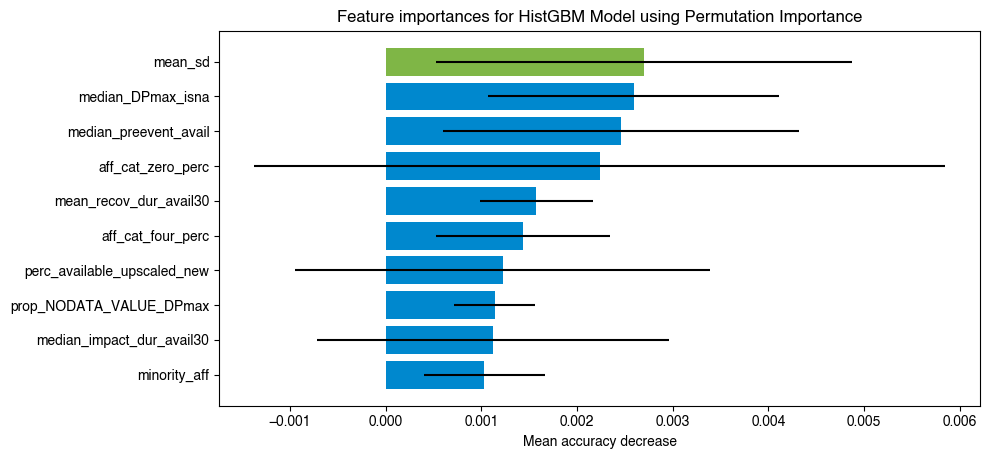

In [104]:
print_feature_importance_pm(
    final_hgbm_model,
    X_test_wo_grid,          
    y_test,          
    X_test_wo_grid.columns,
    "HistGBM", 
    '#0088ce', 
    '#7fb646'
)

Now the best lgbm model:

In [ ]:
best_config_lgbm, best_X_tr_lgbm, best_X_te_lgbm, best_y_tr_lgbm, best_y_te_lgbm, final_lgbm_model = auto_optimize_model(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    X_train_over_wo,
    X_test_wo_grid,
    y_train_over_wo,
    y_test,
    do_gridsearch= True,
    param_grid   = param_grid_lgbm,
    must_include = "perc_available_upscaled_new",
    cv=5
)

# ============================================================
# STEP 1: Baseline
# ============================================================
#   CV R²: 0.1664 | Test R²: 0.1065 | Gap: 0.0599

# ============================================================
# STEP 2: Feature selection
# ============================================================
# Pinning ['perc_available_upscaled_new'] from small group, searching remaining 4 cols
# Subsampled to 200 combinations
# Searching 200 combinations from 12 small groups...
# Best exhaustive combo score: 0.1692

# Final feature count: 59 from original 76

# [Feature selection] ✗ rejected (59 cols from 76)
#   CV R²: 0.1692 | Test R²: 0.0914 | Gap: 0.0778

# ============================================================
# STEP 3: Feature scaling
# ============================================================

# Scaling (StandardScaler)] ✗ rejected 
#   CV R²: 0.1660 | Test R²: 0.0956 | Gap: 0.0703

# [Scaling (MinMaxScaler)] ✗ rejected 
#   CV R²: 0.1626 | Test R²: 0.1023 | Gap: 0.0602

# ============================================================
# STEP 4: Log transform target
# ============================================================

# [Log transform target] ✗ rejected 
#   CV R²: 0.1932 | Test R²: 0.0234 | Gap: 0.1698
# Fitting 5 folds for each of 100 candidates, totalling 500 fits

# [Gridsearch] ✓ accepted best params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'min_gain_to_split': 1.0, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
#   CV R²: 0.1741 | Test R²: 0.1077 | Gap: 0.0664

# ============================================================
# FINAL SUMMARY
# ============================================================
#   Model name:         lgbm_tuned
#   Best Test R²:       0.1077
#   Best Gap:           0.0664
#   Feature selection:  False
#   Scaling:            None
#   Log transform:      False
#   Gridsearch:         True
#   Best params:        {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'min_gain_to_split': 1.0, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
#   Final feature count:76
#   Saved to:           ../models/lgbm_tuned_lc.pkl

print_consistent_results(final_lgbm_model, 
                        X_train_over_wo, y_train_over_wo,
                        X_test_wo_grid, y_test, cv=5)

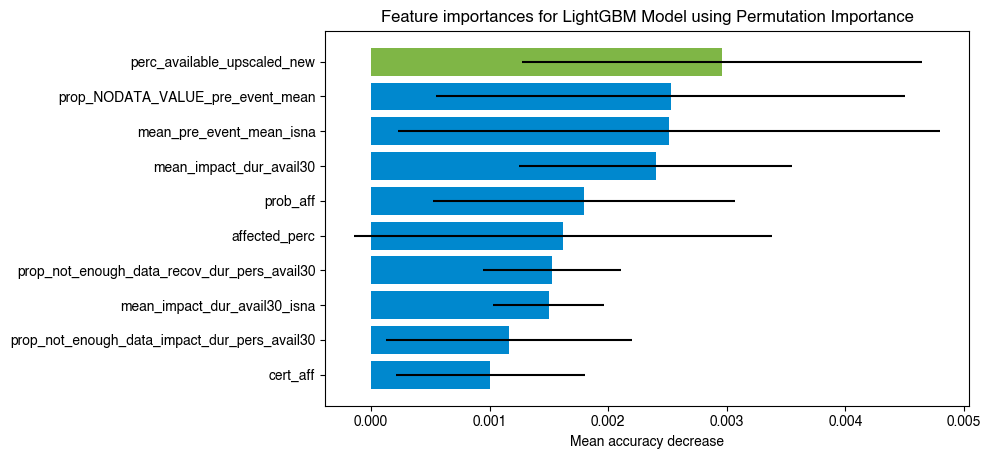

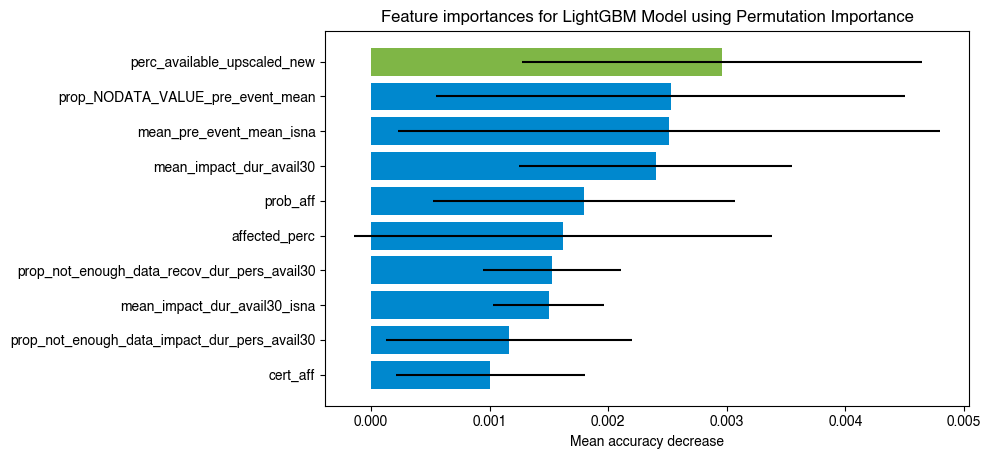

In [101]:
print_feature_importance_pm(
    final_lgbm_model,
    X_test_wo_grid,          
    y_test,          
    X_test_wo_grid.columns,
    "LightGBM",
    '#0088ce', 
    '#7fb646'
)

running quickly again for urban only:

In [108]:
# read in complex filled data
df_uo = pd.read_csv('../data/target/model_training_data_final_urban_only.csv')
# df = df[df['no_aff_data'] == 0]
X_train_uo, X_test_uo, y_train_uo, y_test_uo = clean_and_split_data(df_uo,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

X_train_wo_grid_uo = X_train_uo.drop(columns=['grid_point_id'])
X_test_wo_grid_uo = X_test_uo.drop(columns=['grid_point_id'])

# q25 = y_train.quantile(0.25)
q75 = y_train_uo.quantile(0.75)
# tail_mask_wo = (y_train < q25) | (y_train > q75)
tail_mask_wo = (y_train_uo > q75)

X_tail_wo_uo = X_train_wo_grid_uo[tail_mask_wo]
y_tail_wo_uo = y_train_uo[tail_mask_wo]

n_repeats = 2
noise_X = 0.01
noise_y = 0.01 * y_train.std()

X_augmented_uo = pd.concat([X_tail_wo_uo + np.random.normal(0, noise_X, X_tail_wo_uo.shape) for _ in range(n_repeats)])
y_augmented_uo = pd.concat([y_tail_wo_uo + np.random.normal(0, noise_y, y_tail_wo_uo.shape) for _ in range(n_repeats)])

# clip y to prevent negative values
y_augmented_uo = y_augmented_uo.clip(lower=0)

X_train_over_wo_uo = pd.concat([X_train_wo_grid_uo, X_augmented_uo])
y_train_over_wo_uo = pd.concat([y_train_uo, y_augmented_uo])

print(f"Original size: {len(X_train_wo_grid_uo)}, Oversampled size: {len(X_train_over_wo_uo)}")

print("for LGBM:")
lgb_model_uo = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model_uo.fit(X_train_over_wo_uo, y_train_over_wo_uo)

scores = cross_val_score(lgb_model_uo, X_train_over_wo_uo, y_train_over_wo_uo, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_wo_grid_uo)
test_r2_lgb = r2_score(y_test_uo, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model_uo = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model_uo.fit(X_train_over_wo_uo, y_train_over_wo_uo)

scores = cross_val_score(hgbr_model_uo, X_train_over_wo_uo, y_train_over_wo_uo, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model_uo.predict(X_test_wo_grid_uo)
test_r2_hgbr = r2_score(y_test_uo, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

# n_repeats: 2
# Original size: 24448, Oversampled size: 29936
# for LGBM:
# mean CV score: 0.1572
# Test Set R²: 0.1015
# for HistGradientBoostingRegressor:
# mean CV score: 0.1355
# Test Set R²: 0.0914

# n_repeats: 4
# Original size: 24448, Oversampled size: 35424
# for LGBM:
# mean CV score: 0.2424
# Test Set R²: 0.0949
# for HistGradientBoostingRegressor:
# mean CV score: 0.2326
# Test Set R²: 0.0849



Original size: 24448, Oversampled size: 29936
for LGBM:
mean CV score: 0.1442
Test Set R²: 0.1044
for HistGradientBoostingRegressor:
mean CV score: 0.1206
Test Set R²: 0.0977


In [ ]:
best_config_lgbm_uo, best_X_tr_lgbm_uo, best_X_te_lgbm_uo, best_y_tr_lgbm_uo, best_y_te_lgbm_uo, final_lgbm_model_uo = auto_optimize_model(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    X_train_over_wo_uo,
    X_test_wo_grid_uo,
    y_train_over_wo_uo,
    y_test_uo,
    do_gridsearch= True,
    param_grid   = param_grid_lgbm,
    must_include = "perc_available_upscaled_new",
    cv=5,
    name_add='urban_only'
)

print_consistent_results(final_lgbm_model_uo, 
                        best_X_tr_lgbm_uo, best_y_tr_lgbm_uo,
                        best_X_te_lgbm_uo, best_y_te_lgbm_uo, cv=5)

# Model name:         lgbm_minmax
# Best Test R²:       0.0994
# Best Gap:           0.0446
# Feature selection:  False
# Scaling:            MinMaxScaler
# Log transform:      False
# Gridsearch:         False
# Final feature count:67
# Saved to:           ../models/lgbm_minmax_urban_only.pkl
# Cross-validation R²:   0.1440 ± 0.0230
# Cross-validation RMSE: 6.1730 ± 3.1933
# Test Set R²:           0.0994
# Test Set RMSE:         4.9557

In [ ]:
# CV R²: 0.1476 | Test R²: 0.1047 | Gap: 0.0429
#  CV R²: 0.1741 | Test R²: 0.1077 | Gap: 0.0664

One more attempt to make this model better, going to remove some of the row that have the most missing data.

── Row missingness distribution ──────────────────────
count    39842.0000
mean         0.2384
std          0.0503
min          0.0000
25%          0.2222
50%          0.2222
75%          0.2778
max          0.3056
dtype: float64

Rows with any missing:  39525 (99.2%)
Rows with >10% missing: 39455 (99.0%)
Rows with >25% missing: 12943 (32.5%)
Rows with >50% missing: 0 (0.0%)
Rows with 100% missing: 0 (0.0%)


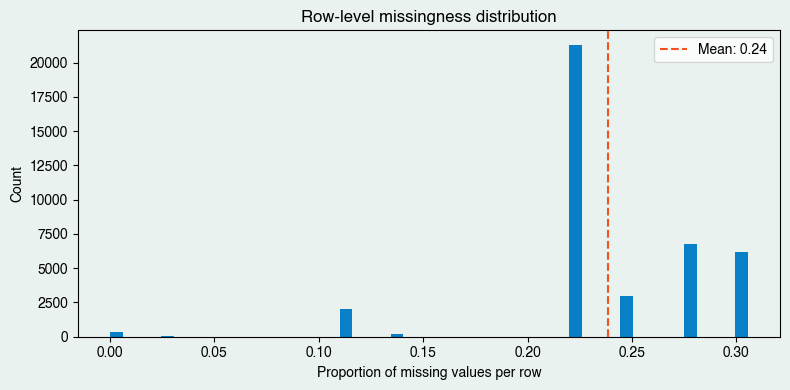

In [47]:
# read in complex filled data
df = pd.read_csv('../data/target/model_training_data_final_2.csv')
# X_train_f, X_test_f, y_train_f, y_test_f = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

# # first just look
miss_stats = describe_row_missingness(df)

# then decide and drop
# df_clean = drop_rows_by_missingness(X_train_f, threshold=0.3)

In [ ]:
# only oversample the upper tail
q75 = y_train_cl.quantile(0.75)
tail_mask_cl = y_train_cl > q75   # upper tail only

X_tail_wo = X_train_wo_grid_cl[tail_mask_cl]
y_tail_wo  = y_train_cl[tail_mask_cl]

n_repeats = 2
noise_X   = 0.01
noise_y   = 0.01 * y_train_cl.std()

X_augmented = pd.concat([X_tail_wo + np.random.normal(0, noise_X, X_tail_wo.shape) for _ in range(n_repeats)])
y_augmented = pd.concat([y_tail_wo + np.random.normal(0, noise_y, y_tail_wo.shape) for _ in range(n_repeats)])
y_augmented = y_augmented.clip(lower=0)

X_train_over_wo_cl = pd.concat([X_train_wo_grid_cl, X_augmented])
y_train_over_wo_cl = pd.concat([y_train_cl, y_augmented])

print(f"Original size: {len(X_train_wo_grid_cl)}, Oversampled size: {len(X_train_over_wo_cl)}")
print(f"Upper tail rows added: {len(X_augmented)}")

In [77]:
df_cleaned = drop_rows_by_missingness(df, 0.25)
X_train_cl, X_test_cl, y_train_cl, y_test_cl = clean_and_split_data(df_cleaned,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

X_train_wo_grid_cl = X_train_cl.drop(columns=['grid_point_id'])
X_test_wo_grid_cl = X_test_cl.drop(columns=['grid_point_id'])

q75 = y_train_cl.quantile(0.75)
tail_mask_cl = y_train_cl > q75   # upper tail only

X_tail_wo = X_train_wo_grid_cl[tail_mask_cl]
y_tail_wo  = y_train_cl[tail_mask_cl]

n_repeats = 2
noise_X   = 0.01
noise_y   = 0.01 * y_train_cl.std()

X_augmented = pd.concat([X_tail_wo + np.random.normal(0, noise_X, X_tail_wo.shape) for _ in range(n_repeats)])
y_augmented = pd.concat([y_tail_wo + np.random.normal(0, noise_y, y_tail_wo.shape) for _ in range(n_repeats)])

# clip y to prevent negative values
y_augmented = y_augmented.clip(lower=0)

X_train_over_wo_cl = pd.concat([X_train_wo_grid_cl, X_augmented])
y_train_over_wo_cl = pd.concat([y_train_cl, y_augmented])

print(f"Original size: {len(X_train_wo_grid_lc)}, Oversampled size: {len(X_train_over_wo_lc)}")

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_over_wo_cl, y_train_over_wo_cl)

scores = cross_val_score(lgb_model, X_train_over_wo_cl, y_train_over_wo_cl, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_wo_grid_cl)
test_r2_lgb = r2_score(y_test_cl, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_over_wo_cl, y_train_over_wo_cl)

scores = cross_val_score(hgbr_model, X_train_over_wo_cl, y_train_over_wo_cl, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_wo_grid_cl)
test_r2_hgbr = r2_score(y_test_cl, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

# n_repeats: 2 0.2778 thresh
# Dropped 6165 rows above 28% missingness threshold
# Remaining: 33677 from 39842
# Original size: 24448, Oversampled size: 29178
# for LGBM:
# mean CV score: 0.2230
# Test Set R²: 0.1475
# for HistGradientBoostingRegressor:
# mean CV score: 0.1759
# Test Set R²: 0.1505

# 2578
# Dropped 12943 rows above 25% missingness threshold
# Remaining: 26899 from 39842
# Original size: 24448, Oversampled size: 29178
# for LGBM:
# mean CV score: 0.1569
# Test Set R²: 0.1248
# for HistGradientBoostingRegressor:
# mean CV score: 0.1646
# Test Set R²: 0.1437


Dropped 12943 rows above 25% missingness threshold
Remaining: 26899 from 39842
Original size: 24448, Oversampled size: 29178
for LGBM:
mean CV score: 0.1576
Test Set R²: 0.1284
for HistGradientBoostingRegressor:
mean CV score: 0.1598
Test Set R²: 0.1401


In [71]:
print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_wo_grid_cl, y_train_cl)

y_pred_baseline = lgb_model.predict(X_test_wo_grid_cl)
print(f"Baseline Test R²: {r2_score(y_test_cl, y_pred_baseline):.4f}")

print_consistent_results(lgb_model, X_train_wo_grid_cl, y_train_cl, X_test_wo_grid_cl, y_test_cl, cv=5)

# Baseline R²: -0.0413
# Baseline Test R²: -0.0162
# Cross-validation R²:   -0.0659 ± 0.0624
# Cross-validation RMSE: 8.6888 ± 4.5937
# Test Set R²:           -0.0162
# Test Set RMSE:         5.2641

for LGBM:
Baseline Test R²: 0.1208
Cross-validation R²:   0.0771 ± 0.0605
Cross-validation RMSE: 4.5798 ± 0.5252
Test Set R²:           0.1208
Test Set RMSE:         4.9351


In [ ]:
param_grid_hgb = {
    "max_iter":        [100, 200, 300],
    "max_depth":       [3, 5, 7, None],
    "learning_rate":   [0.01, 0.05, 0.1],
    "min_samples_leaf":[10, 20, 50],
    "l2_regularization":[0.0, 0.1, 1.0],
}

best_config_hgb_dr, best_X_tr_hgb_dr, best_X_te_hgb_dr, best_y_tr_hgb_dr, best_y_te_hgb_dr, final_hgb_dr_model = auto_optimize_model(
    HistGradientBoostingRegressor(random_state=42,verbose=0),
    X_train_over_wo_cl,
    X_test_wo_grid_cl,
    y_train_over_wo_cl, 
    y_test_cl,
    do_gridsearch= True,
    param_grid   = param_grid_hgb,
    cv=4,
    max_gap=0.1,
)

print_consistent_results(final_hgb_dr_model, 
                        best_X_tr_hgb_dr, best_y_tr_hgb_dr,
                        best_X_te_hgb_dr, best_y_te_hgb_dr, cv=5)

#   Model name:         lgbm_minmax
#   Best Test R²:       0.1377
#   Best Gap:           0.0845
#   Feature selection:  False
#   Scaling:            MinMaxScaler
#   Log transform:      False
#   Gridsearch:         False
#   Final feature count:63
#   Saved to:           ../models/lgbm_minmax_dropped.pkl
# Cross-validation R²:   0.1448 ± 0.1120
# Cross-validation RMSE: 6.1829 ± 3.4466
# Test Set R²:           0.1377
# Test Set RMSE:         4.8874

In [3]:
df = pd.read_csv('../data/target/model_training_data_final.csv')
# df

In [ ]:
def find_null_values_in_cols(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0]

def get_na_columns(df,thresh=0):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > thresh].keys()

In [6]:
find_null_values_in_cols(df)/df.shape[0]

mean_DPmax                        0.324682
median_DPmax                      0.324682
mean_pre_event_mean               0.154736
median_pre_event_mean             0.154736
mean_impact_dur_avail50           0.990287
median_impact_dur_avail50         0.990287
mean_impact_dur_pers_avail50      0.990287
median_impact_dur_pers_avail50    0.990287
mean_impact_dur_avail30           0.933462
median_impact_dur_avail30         0.933462
mean_impact_dur_pers_avail30      0.933462
median_impact_dur_pers_avail30    0.933462
mean_preevent_avail               0.343883
median_preevent_avail             0.343883
mean_recov_dur_avail50            0.990287
median_recov_dur_avail50          0.990287
mean_recov_dur_avail30            0.933462
median_recov_dur_avail30          0.933462
mean_recov_dur_pers_avail50       0.990287
median_recov_dur_pers_avail50     0.990287
mean_recov_dur_pers_avail30       0.933462
median_recov_dur_pers_avail30     0.933462
mean_sd                           0.062597
median_sd  

Drop columns that are too null:
- 99% not available: num = 39455
- 93% not available: num. = 37191

using the function:
`get_na_columns(df,thresh=0)`

In [ ]:
# 99% num = 39455
# 93% num. = 37191

cols_99 = get_na_columns(df,thresh=39455)
cols_93 = get_na_columns(df,thresh=37191)

df_99 = df.drop(columns=cols_99)
df_93 = df.drop(columns=cols_93)



In [ ]:
describe_row_missingness(df_93)

# 25% 0.1250
# std 0.0521

In [77]:
describe_row_missingness(df_99)

# 25% 0.2222
# std 0.0503

── Row missingness distribution ──────────────────────
count    39842.0000
mean         0.2384
std          0.0503
min          0.0000
25%          0.2222
50%          0.2222
75%          0.2778
max          0.3056
dtype: float64

Rows with any missing:  39525 (99.2%)
Rows with >10% missing: 39455 (99.0%)
Rows with >25% missing: 12943 (32.5%)
Rows with >50% missing: 0 (0.0%)
Rows with 100% missing: 0 (0.0%)


0        0.305556
1        0.305556
2        0.305556
3        0.222222
4        0.222222
           ...   
39837    0.222222
39838    0.222222
39839    0.222222
39840    0.222222
39841    0.222222
Length: 39842, dtype: float64